# Лабораторная 2. Идентификация выбросов с помощью kNN и ODIN

**Задание.** Сгенерировать обучающую выборку для решения задачи распознавания
растровых изображений, содержащую выбросы типа 0. Назовём выбросы этого типа
выбросами типа 1, если они не распознаются как выбросы с помощью метода
ближайшего соседа, выбросами типа 2 - выбросы типа 0, которые не распознаются
с помощью метода ODIN. Реализовать оба подхода к идентификации выбросов.
Сравнить результаты их работы.

## 1. Теория

### Данные

MNIST, изображения $28 \times 28$ в градациях серого, 10 классов. Берётся
стратифицированная подвыборка из 1800 изображений, в неё вносятся выбросы трёх
видов по 60 штук каждого: перепутанная метка (изображение не тронуто, метка
заменена на случайную чужую), сильная порча ($60\%$ пикселей заменены случайными
значениями, метка верна), поворот на 180 градусов (метка исходная). Чистые
изображения берутся из первой половины обучающей выборки MNIST, выбросы делаются
из второй, поэтому точных копий выбросов среди чистых нет.

### Выброс

Выброс это элемент выборки, который метод ближайшего соседа классифицирует
неправильно по остальным элементам выборки (схема leave-one-out): ближайшими к
нему оказываются объекты чужих классов.

| Тип | Что это |
|-----|---------|
| 0 | выбросы, внесённые в выборку намеренно, для них известна истина |
| 1 | выбросы типа 0, которые не обнаружил метод ближайшего соседа |
| 2 | выбросы типа 0, которые не обнаружил ODIN |

### Детекторы

Метод ближайшего соседа. Для элемента $x^{(i)}$ берутся $k$ ближайших к нему
элементов выборки, кроме него самого, и преобладающая среди них метка. Если она
не совпадает с $y^{(i)}$, элемент помечается выбросом.

ODIN (Outlier Detection using Indegree Number) меток не использует. Строится
ориентированный граф $k$ ближайших соседей: ребро $i \to j$ проводится, если
$x^{(j)}$ входит в число $k$ ближайших к $x^{(i)}$. Входящая степень вершины

$$\deg^{-}(j) = \bigl\lvert\{\, i : j \in N_k(i) \,\}\bigr\rvert$$

считает, для скольких элементов $x^{(j)}$ оказался соседом. Элемент помечается
выбросом, если $\deg^{-}(j) < T$.

### Мера близости

Евклидово расстояние между векторами яркостей длины $m = 784$:
$\rho(x, z) = \sqrt{\sum_j (x_j - z_j)^2}$, значения пикселей поделены на 255.

### Что перебирается

| Гиперпараметр | Значения |
|---|---|
| $k$, оба детектора | 1, 3, 5, 7, 9, 11, 15, 20 |
| порог $T$, ODIN | от 0 до $\min(k, 6)$ |

### Меры качества

$$\text{precision} = \frac{TP}{TP + FP}, \qquad
\text{recall} = \frac{TP}{TP + FN}, \qquad
F_1 = \frac{2\,\text{precision} \cdot \text{recall}}{\text{precision} + \text{recall}},$$

где $TP$ это верно помеченные выбросы, $FP$ помеченные чистые элементы,
$FN$ пропущенные выбросы.

## 2. Данные и внесение выбросов

In [1]:
import os
import struct
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RNG = np.random.default_rng(20260905)
plt.rcParams['figure.dpi'] = 110

In [2]:
def read_idx(path):
    with open(path, 'rb') as f:
        magic, = struct.unpack('>I', f.read(4))
        dims = struct.unpack('>' + 'I' * (magic & 0xff), f.read(4 * (magic & 0xff)))
        return np.frombuffer(f.read(), dtype=np.uint8).reshape(dims)


def mnist_dir():
    for c in [os.environ.get('MNIST_DIR'),
              '../../bachelor/Perceptron/data_generation/MNIST/raw',
              'data/MNIST/raw']:
        if c and Path(c, 'train-images-idx3-ubyte').exists():
            return Path(c)
    raise FileNotFoundError('не найдены файлы MNIST')


D = mnist_dir()
X_all = read_idx(D / 'train-images-idx3-ubyte')
y_all = read_idx(D / 'train-labels-idx1-ubyte')


def stratified(X, y, per_class, rng):
    idx = np.concatenate([rng.choice(np.flatnonzero(y == c), per_class, replace=False)
                          for c in range(10)])
    rng.shuffle(idx)
    return X[idx].copy(), y[idx].copy()


# чистые изображения из первой половины MNIST, выбросы потом делаются из второй
X_clean, y_clean = stratified(X_all[:30000], y_all[:30000], 180, RNG)
print(f'чистая выборка: {X_clean.shape}, по классам {np.bincount(y_clean)}')

чистая выборка: (1800, 28, 28), по классам [180 180 180 180 180 180 180 180 180 180]


In [3]:
N_OUT = 60


def make_outliers(X_pool, y_pool, rng):
    """Три вида выбросов по N_OUT штук: чужая метка, порча пикселей, поворот."""
    parts, labels, kinds = [], [], []

    idx = rng.choice(len(X_pool), N_OUT, replace=False)
    # прибавление случайного числа от 1 до 9 по модулю 10 даёт заведомо чужую метку
    wrong = (y_pool[idx] + rng.integers(1, 10, N_OUT)) % 10
    parts.append(X_pool[idx].copy()); labels.append(wrong)
    kinds += ['перепутанная метка'] * N_OUT

    idx = rng.choice(len(X_pool), N_OUT, replace=False)
    img = X_pool[idx].copy()
    mask = rng.random(img.shape) < 0.6
    img[mask] = rng.integers(0, 256, mask.sum(), dtype=np.uint8)
    parts.append(img); labels.append(y_pool[idx].copy())
    kinds += ['сильная порча'] * N_OUT

    idx = rng.choice(len(X_pool), N_OUT, replace=False)
    # [::-1, ::-1] переворачивает изображение по обеим осям, это поворот на 180
    parts.append(X_pool[idx][:, ::-1, ::-1].copy()); labels.append(y_pool[idx].copy())
    kinds += ['поворот 180'] * N_OUT

    return np.concatenate(parts), np.concatenate(labels), np.array(kinds)


pool_X, pool_y = stratified(X_all[30000:], y_all[30000:], 400, np.random.default_rng(7))
X_out, y_out, kind_out = make_outliers(pool_X, pool_y, RNG)

X = np.concatenate([X_clean, X_out])
y = np.concatenate([y_clean, y_out])
kind = np.array(['чистый'] * len(X_clean) + list(kind_out))
is_outlier = kind != 'чистый'

perm = RNG.permutation(len(X))
X, y, kind, is_outlier = X[perm], y[perm], kind[perm], is_outlier[perm]

print(f'выборка: {len(X)} элементов, выбросов типа 0: {is_outlier.sum()} '
      f'({is_outlier.mean():.1%})')
print(pd.Series(kind).value_counts().to_string())

выборка: 1980 элементов, выбросов типа 0: 180 (9.1%)
чистый                1800
поворот 180             60
сильная порча           60
перепутанная метка      60


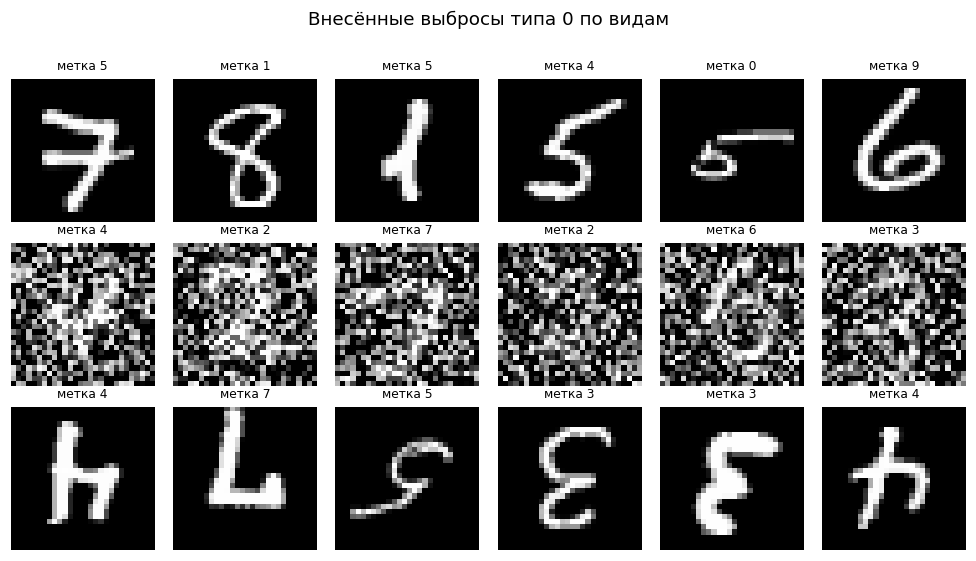

In [4]:
fig, axes = plt.subplots(3, 6, figsize=(9, 5))
for row, k in enumerate(['перепутанная метка', 'сильная порча', 'поворот 180']):
    idx = np.flatnonzero(kind == k)[:6]
    for col, j in enumerate(idx):
        axes[row, col].imshow(X[j], cmap='gray')
        axes[row, col].set_title(f'метка {y[j]}', fontsize=8)
        axes[row, col].axis('off')
    axes[row, 0].set_ylabel(k, fontsize=8)
fig.suptitle('Внесённые выбросы типа 0 по видам', y=1.01)
plt.tight_layout()
plt.show()

## 3. Реализация детекторов

In [5]:
def distances(X):
    """Матрица попарных расстояний L2 между изображениями выборки."""
    A = X.reshape(len(X), -1).astype(np.float32) / 255.0
    d = np.empty((len(A), len(A)), dtype=np.float32)
    for i in range(len(A)):
        # A - A[i] вычитает i-е изображение из каждой строки, дальше норма по строкам
        d[i] = np.sqrt(((A - A[i]) ** 2).sum(axis=1))
    np.fill_diagonal(d, np.inf)  # элемент не может быть соседом самому себе
    return d


def knn_flag(dist, y, k):
    """Выброс, если преобладающая метка k ближайших соседей не совпадает со своей."""
    flag = np.zeros(len(dist), dtype=bool)
    for i in range(len(dist)):
        nn = np.argsort(dist[i])[:k]  # номера k ближайших к i-му элементу
        votes = np.bincount(y[nn], minlength=10)  # сколько соседей у каждого класса
        flag[i] = votes.argmax() != y[i]
    return flag


def odin_indegree(dist, k):
    """Сколько раз элемент попал в число k ближайших соседей остальных элементов."""
    deg = np.zeros(len(dist), dtype=int)
    for i in range(len(dist)):
        for j in np.argsort(dist[i])[:k]:  # ребро из i в j для каждого из k соседей
            deg[j] += 1
    return deg


dist = distances(X)
print(f'матрица расстояний {dist.shape}')

матрица расстояний (1980, 1980)


## 4. Подбор параметров

In [6]:
def scores(flag, truth):
    """precision, recall и F1 для булева признака flag против истины truth."""
    tp = int((flag & truth).sum())
    fp = int((flag & ~truth).sum())
    fn = int((~flag & truth).sum())
    precision = tp / (tp + fp) if tp + fp else 0.0
    recall = tp / (tp + fn) if tp + fn else 0.0
    f1 = 2 * precision * recall / (precision + recall) if precision + recall else 0.0
    return precision, recall, f1


rows = []
for k in [1, 3, 5, 7, 9, 11, 15, 20]:
    p, r, f = scores(knn_flag(dist, y, k), is_outlier)
    rows.append(dict(method='kNN', k=k, threshold=np.nan,
                     precision=p, recall=r, f1=f))
    ind = odin_indegree(dist, k)
    for T in range(0, min(k, 6) + 1):
        p, r, f = scores(ind < T, is_outlier)
        rows.append(dict(method='ODIN', k=k, threshold=T,
                         precision=p, recall=r, f1=f))

res = pd.DataFrame(rows)
res.to_csv('results.csv', index=False)
print(f'{len(res)} конфигураций')
print(res[res.method == 'kNN'].round(3).to_string(index=False))

55 конфигураций
method  k  threshold  precision  recall    f1
   kNN  1        NaN      0.331   0.594 0.425
   kNN  3        NaN      0.373   0.589 0.457
   kNN  5        NaN      0.368   0.572 0.448
   kNN  7        NaN      0.369   0.617 0.462
   kNN  9        NaN      0.349   0.611 0.444
   kNN 11        NaN      0.344   0.622 0.443
   kNN 15        NaN      0.327   0.611 0.426
   kNN 20        NaN      0.323   0.622 0.425


In [7]:
best_odin = res[res.method == 'ODIN'].sort_values('f1', ascending=False).head(10)
print(best_odin.round(3).to_string(index=False))

method  k  threshold  precision  recall    f1
  ODIN 20        5.0      0.444   0.417 0.430
  ODIN 20        6.0      0.377   0.467 0.417
  ODIN 20        4.0      0.488   0.350 0.408
  ODIN 15        4.0      0.387   0.417 0.401
  ODIN  9        3.0      0.325   0.517 0.399
  ODIN 15        5.0      0.336   0.489 0.398
  ODIN 15        3.0      0.450   0.350 0.394
  ODIN 11        4.0      0.312   0.533 0.393
  ODIN 15        6.0      0.296   0.544 0.384
  ODIN 11        3.0      0.351   0.411 0.379


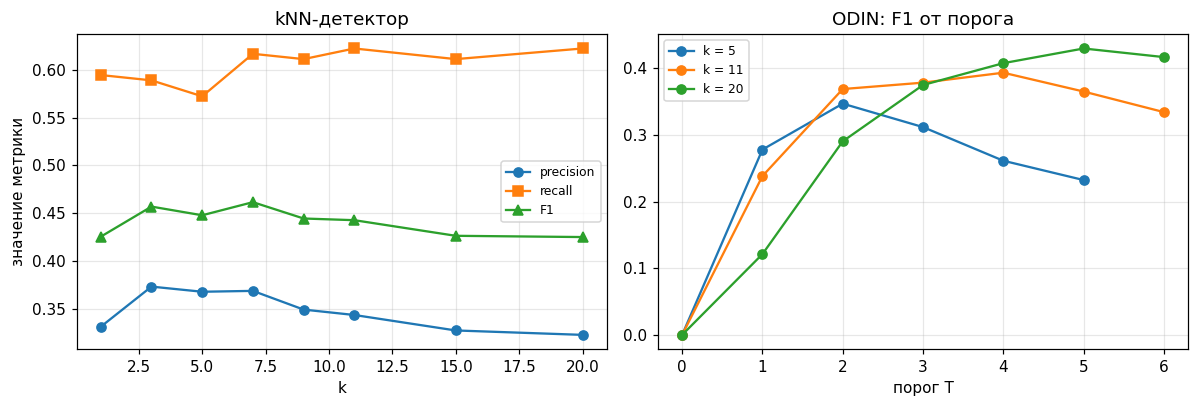

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
sub = res[res.method == 'kNN']
axes[0].plot(sub.k, sub.precision, marker='o', label='precision')
axes[0].plot(sub.k, sub.recall, marker='s', label='recall')
axes[0].plot(sub.k, sub.f1, marker='^', label='F1')
axes[0].set_title('kNN-детектор')
axes[0].set_xlabel('k'); axes[0].grid(alpha=0.3); axes[0].legend(fontsize=8)

for k in [5, 11, 20]:
    s = res[(res.method == 'ODIN') & (res.k == k)].sort_values('threshold')
    axes[1].plot(s.threshold, s.f1, marker='o', label=f'k = {k}')
axes[1].set_title('ODIN: F1 от порога')
axes[1].set_xlabel('порог T'); axes[1].grid(alpha=0.3); axes[1].legend(fontsize=8)
axes[0].set_ylabel('значение метрики')
plt.tight_layout()
plt.show()

## 5. Выбросы типа 1 и типа 2

In [9]:
K_KNN = int(res[res.method == 'kNN'].sort_values('f1').iloc[-1].k)
best_o = res[res.method == 'ODIN'].sort_values('f1').iloc[-1]
K_ODIN, T_ODIN = int(best_o.k), int(best_o.threshold)
print(f'выбраны параметры: kNN k = {K_KNN}; ODIN k = {K_ODIN}, T = {T_ODIN}')

flag_knn = knn_flag(dist, y, K_KNN)
flag_odin = odin_indegree(dist, K_ODIN) < T_ODIN

type1 = is_outlier & ~flag_knn
type2 = is_outlier & ~flag_odin

print(f'выбросов типа 0: {is_outlier.sum()}')
print(f'выбросов типа 1 (пропустил kNN):  {type1.sum()} ({type1.sum() / is_outlier.sum():.1%})')
print(f'выбросов типа 2 (пропустил ODIN): {type2.sum()} ({type2.sum() / is_outlier.sum():.1%})')
print(f'пропущены обоими: {(type1 & type2).sum()}')
print(f'пойманы обоими:   {(flag_knn & flag_odin & is_outlier).sum()}')

выбраны параметры: kNN k = 7; ODIN k = 20, T = 5


выбросов типа 0: 180
выбросов типа 1 (пропустил kNN):  69 (38.3%)
выбросов типа 2 (пропустил ODIN): 105 (58.3%)
пропущены обоими: 19
пойманы обоими:   25


In [10]:
by_kind = pd.DataFrame({
    'всего': pd.Series(kind[is_outlier]).value_counts(),
    'поймал kNN': pd.Series(kind[is_outlier & flag_knn]).value_counts(),
    'поймал ODIN': pd.Series(kind[is_outlier & flag_odin]).value_counts(),
}).fillna(0).astype(int)
by_kind['тип 1'] = by_kind['всего'] - by_kind['поймал kNN']
by_kind['тип 2'] = by_kind['всего'] - by_kind['поймал ODIN']
print(by_kind.to_string())

                    всего  поймал kNN  поймал ODIN  тип 1  тип 2
перепутанная метка     60          59            6      1     54
поворот 180            60          43           18     17     42
сильная порча          60           9           51     51      9


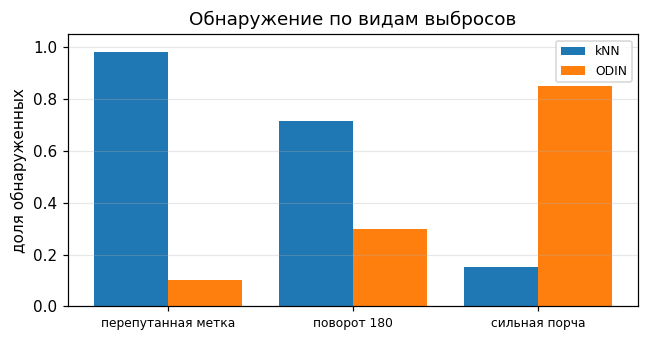

In [11]:
fig, ax = plt.subplots(figsize=(6, 3.2))
labels = list(by_kind.index)
xs = np.arange(len(labels))
ax.bar(xs - 0.2, by_kind['поймал kNN'] / by_kind['всего'], 0.4, label='kNN')
ax.bar(xs + 0.2, by_kind['поймал ODIN'] / by_kind['всего'], 0.4, label='ODIN')
ax.set_xticks(xs); ax.set_xticklabels(labels, fontsize=8)
ax.set_ylabel('доля обнаруженных'); ax.set_ylim(0, 1.05)
ax.set_title('Обнаружение по видам выбросов'); ax.legend(fontsize=8)
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

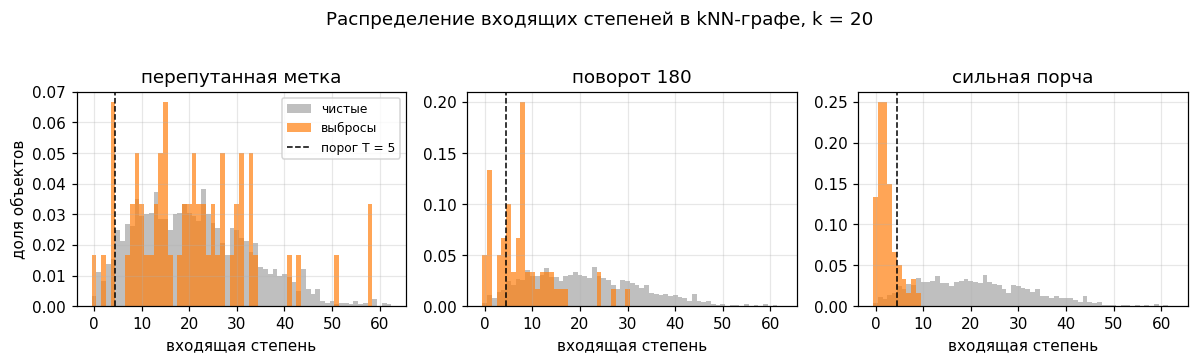

In [12]:
ind = odin_indegree(dist, K_ODIN)
# границы на полуцелых: каждое целое значение степени попадает в свой столбик
bins = np.arange(0, ind.max() + 2) - 0.5
fig, axes = plt.subplots(1, 3, figsize=(11, 3.2), sharex=True)
for ax, name in zip(axes, ['перепутанная метка', 'поворот 180', 'сильная порча']):
    # при ширине столбика 1 density=True даёт долю объектов своей группы
    ax.hist(ind[kind == 'чистый'], bins=bins, density=True, color='gray', alpha=0.5, label='чистые')
    ax.hist(ind[kind == name], bins=bins, density=True, color='C1', alpha=0.7, label='выбросы')
    ax.axvline(T_ODIN - 0.5, color='black', ls='--', lw=1, label=f'порог T = {T_ODIN}')
    ax.set_title(name)
    ax.set_xlabel('входящая степень')
    ax.grid(alpha=0.3)
axes[0].set_ylabel('доля объектов')
axes[0].legend(fontsize=8)
fig.suptitle(f'Распределение входящих степеней в kNN-графе, k = {K_ODIN}', y=1.02)
plt.tight_layout()
plt.show()

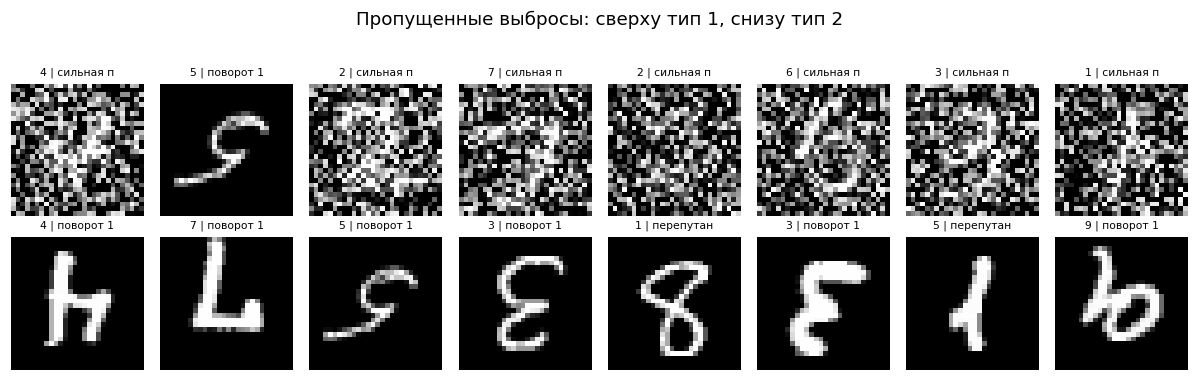

In [13]:
fig, axes = plt.subplots(2, 8, figsize=(11, 3.4))
for row, (mask, name) in enumerate([(type1, 'тип 1: пропустил kNN'),
                                    (type2, 'тип 2: пропустил ODIN')]):
    idx = np.flatnonzero(mask)[:8]
    for col in range(8):
        ax = axes[row, col]
        ax.axis('off')
        if col < len(idx):
            j = idx[col]
            ax.imshow(X[j], cmap='gray')
            ax.set_title(f'{y[j]} | {kind[j][:9]}', fontsize=7)
    axes[row, 0].set_ylabel(name, fontsize=8)
fig.suptitle('Пропущенные выбросы: сверху тип 1, снизу тип 2', y=1.03)
plt.tight_layout()
plt.show()

## 6. Совместная работа детекторов

In [14]:
both = flag_knn & flag_odin
only_knn = flag_knn & ~flag_odin
only_odin = flag_odin & ~flag_knn
neither = ~flag_knn & ~flag_odin

table = pd.DataFrame({
    'выбросы типа 0': [int((both & is_outlier).sum()), int((only_knn & is_outlier).sum()),
                       int((only_odin & is_outlier).sum()), int((neither & is_outlier).sum())],
    'чистые': [int((both & ~is_outlier).sum()), int((only_knn & ~is_outlier).sum()),
               int((only_odin & ~is_outlier).sum()), int((neither & ~is_outlier).sum())],
}, index=['помечены обоими', 'только kNN', 'только ODIN', 'не помечены'])
print(table.to_string())

                 выбросы типа 0  чистые
помечены обоими              25      31
только kNN                   86     159
только ODIN                  50      63
не помечены                  19    1547


In [15]:
for name, flag in [('kNN', flag_knn), ('ODIN', flag_odin),
                   ('объединение', flag_knn | flag_odin),
                   ('пересечение', flag_knn & flag_odin)]:
    p, r, f = scores(flag, is_outlier)
    print(f'{name:12s} precision={p:.3f}  recall={r:.3f}  F1={f:.3f}  '
          f'помечено {int(flag.sum())}')

kNN          precision=0.369  recall=0.617  F1=0.462  помечено 301
ODIN         precision=0.444  recall=0.417  F1=0.430  помечено 169
объединение  precision=0.389  recall=0.894  F1=0.542  помечено 414
пересечение  precision=0.446  recall=0.139  F1=0.212  помечено 56
